# Micro Research Note Experiment: ARIMA accuracy vs volatility regime

**Outputs created by this notebook**
- `output/metrics_table.csv`
- `figures/figure1_actual_vs_forecast.png`
**Experiment steps**
In daily-life terms:
- **Data cleaning** = washing ingredients
- **Regime windows** = choosing a calm vs a busy time of day
- **Model + metrics** = timing your commute on both days and comparing errors

## 0) Setup

In [ ]:
import os,sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(r"../")
from src.arima_volatility import compute_returns, rolling_volatility, select_arima_order_aic, fit_forecast_evaluate

DATA_PATH = os.path.join('..', 'data', 'nav.csv')  # <-- put your file here\n
FIG_DIR = os.path.join('..', 'figures')
OUT_DIR = os.path.join('..', 'output')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

VOL_WINDOW = 20     # rolling window W\n
HORIZON = 12        # forecast steps H (10–15 is typical for a micro note)\n
RET_KIND = 'log'    # 'log' or 'simple'\n

print('Setup done.')

Setup done.


## 1) Load NAV data

In [9]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['Date'])
df = df.sort_values('date').dropna(subset=['NAV'])
df['NAV'] = df['NAV'].astype(float)

display(df.head())
display(df.tail())
print('N =', len(df))

,Date,NAV,date
1,2022-10-25,10.0000,2022-10-25
2,2022-10-27,10.0000,2022-10-27
3,2022-10-28,10.0000,2022-10-28
4,2022-10-31,10.0011,2022-10-31
5,2022-11-01,10.0054,2022-11-01


,Date,NAV,date
746,2026-01-20,14.5964,2026-01-20
747,2026-01-21,14.5485,2026-01-21
748,2026-01-22,14.6390,2026-01-22
749,2026-01-27,14.5444,2026-01-27
750,2026-01-28,14.7175,2026-01-28


N = 747


## 2) Compute returns and rolling volatility

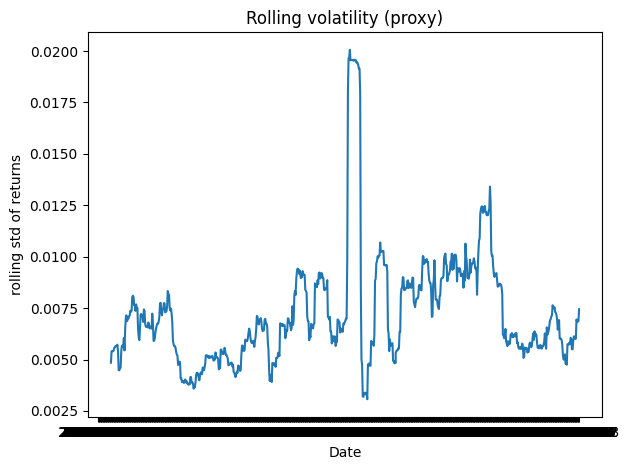

Saved: ..\figures\figure1_rolling_volatility.png


In [17]:
fig = plt.figure()
plt.plot(df['Date'], df['vol'])
plt.title('Rolling volatility (proxy)')
plt.xlabel('Date')
plt.ylabel('rolling std of returns')
plt.tight_layout()

fig1_path = os.path.join(FIG_DIR, "figure1_rolling_volatility.png")
plt.savefig(fig1_path, dpi=200)
plt.show()

print("Saved:", fig1_path)


## 3) Choose your Normal and Volatile windows (manual dates)

Pick two windows of similar length L (e.g., 120 observations):
- **Normal**: volatility stays relatively low
- **Volatile**: volatility spikes

Tip: start by reading the volatility plot and choosing two date ranges.

In [11]:
# TODO: set these dates based on your volatility plot
NORMAL_START = '2023-04-26'
NORMAL_END   = '2023-07-21'

VOL_START    = '2024-04-02'
VOL_END      = '2024-07-03'
def slice_window(dfx, start, end):
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    return dfx[(dfx['date'] >= s) & (dfx['date'] <= e)].copy()
df_normal = slice_window(df, NORMAL_START, NORMAL_END)
df_vol    = slice_window(df, VOL_START, VOL_END)

print('Normal window:', df_normal['date'].min(), 'to', df_normal['date'].max(), '| N=', len(df_normal))
print('Volatile window:', df_vol['date'].min(), 'to', df_vol['date'].max(), '| N=', len(df_vol))

Normal window: 2023-04-26 00:00:00 to 2023-07-21 00:00:00 | N= 60
Volatile window: 2024-04-02 00:00:00 to 2024-07-03 00:00:00 | N= 60


## 4) Fit ARIMA in each window, forecast, evaluate
We select ARIMA(p,d,q) by **lowest AIC** on the training part of each window.

In [13]:
def run_one_regime(df_window, label):
    y = df_window.set_index('date')['NAV']
    sel = select_arima_order_aic(y)
    metrics = fit_forecast_evaluate(y, horizon=HORIZON, order=sel.order)
    return {
        'regime': label,
        'arima_order': str(sel.order),
        'aic': sel.aic,
        **metrics
    }

res_normal = run_one_regime(df_normal, 'Normal')
res_vol    = run_one_regime(df_vol, 'Volatile')

metrics_df = pd.DataFrame([res_normal, res_vol])
metrics_df

c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

,regime,arima_order,aic,mae,rmse,mape_pct
0,Normal,"(2, 1, 2)",-189.558684,0.107585,0.146255,0.977692
1,Volatile,"(1, 1, 0)",-51.588280,0.200412,0.249157,1.405122


## 5) Create Figure 1: Actual vs Forecast (both regimes)\n
\n
Keep it **one figure**: either two panels or overlay lines with clear legend.

c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\datat\OneDrive - Data Tinker\research\arima_micro_note\micro-research-note-arima-volatility\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

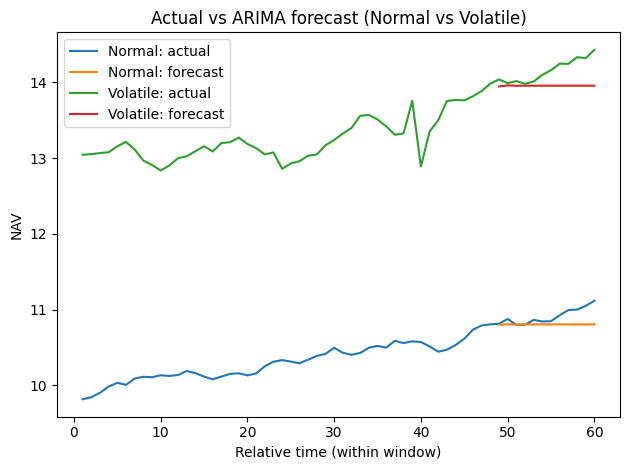

Saved: ..\figures\figure2_actual_vs_forecast_relative.png


In [18]:
from statsmodels.tsa.arima.model import ARIMA
def fit_and_forecast_series(df_window, order):
    y = df_window.set_index('date')['NAV'].astype(float)
    train = y.iloc[:-HORIZON]
    test = y.iloc[-HORIZON:]
    model = ARIMA(train, order=order).fit()
    fc = model.forecast(steps=HORIZON)
    return y, train, test, fc

order_normal = eval(res_normal['arima_order'])
order_vol    = eval(res_vol['arima_order'])

yN, trN, teN, fcN = fit_and_forecast_series(df_normal, order_normal)
yV, trV, teV, fcV = fit_and_forecast_series(df_vol, order_vol)

import numpy as np

# Relative x-axis (1..N) inside each window
xN = np.arange(len(yN)) + 1
xV = np.arange(len(yV)) + 1

fig = plt.figure()
plt.plot(xN, yN.values, label="Normal: actual")
plt.plot(xN[-HORIZON:], fcN.values, label="Normal: forecast")

plt.plot(xV, yV.values, label="Volatile: actual")
plt.plot(xV[-HORIZON:], fcV.values, label="Volatile: forecast")

plt.xlabel("Relative time (within window)")
plt.ylabel("NAV")
plt.title("Actual vs ARIMA forecast (Normal vs Volatile)")
plt.legend()
plt.tight_layout()

fig2_path = os.path.join(FIG_DIR, "figure2_actual_vs_forecast_relative.png")
plt.savefig(fig2_path, dpi=200)
plt.show()

print("Saved:", fig2_path)


## 6) Save Table 1 values

In [16]:
out_path = os.path.join(OUT_DIR, 'metrics_table.csv')
metrics_df.to_csv(out_path, index=False)
print('Saved:', out_path)

metrics_df[['regime','arima_order','mae','rmse','mape_pct']]

Saved: ..\output\metrics_table.csv


,regime,arima_order,mae,rmse,mape_pct
0,Normal,"(2, 1, 2)",0.107585,0.146255,0.977692
1,Volatile,"(1, 1, 0)",0.200412,0.249157,1.405122


## 7) Paste into the micro research note

Open `paper/micro_research_note_template_ajay_saxena.docx` and fill:
- Section 2 (Data)
- Section 3 (Windows used)
- Table 1 (from `output/metrics_table.csv`)
- Figure 1 (insert `figures/figure1_actual_vs_forecast.png`)
